# 03 — Resultados da avaliación RAG

Resultados da avaliación das configuracións RAG sobre o corpus de dereitos de autor da UE (EUR-Lex). Estratexia de ablación incremental (*carry-forward*): cada fase fixa os gañadores das anteriores e varía unha dimensión, *ceteris paribus*. Criterio de decisión: **context_recall + context_precision**. Avaliación con RAGAS (xuíz: gemini-2.5-flash) sobre 50 pares QA.

As fases preséntanse en orde de *pipeline*: embedding → chunking → recuperación → **expansión de consulta (exp4)** → **reranking (exp5)**. Cada técnica compárase coa liña base da súa propia fase.

**Cadea gañadora:** bge-m3 → chunk fixed 256/ov25 → mmr k10 → cross-encoder rerank (ce k10). As sete técnicas de expansión de consulta non melloraron a liña base.

In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

REPORT  = Path('..') / 'data' / '08_reporting'
FIGURES = REPORT / 'results' / 'figures'
TABLES  = REPORT / 'results' / 'tables'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

METRICS  = ['context_recall', 'context_precision', 'context_entity_recall',
            'faithfulness', 'answer_relevancy', 'noise_sensitivity(mode=relevant)']
SHORT = {'context_recall': 'ctx_recall', 'context_precision': 'ctx_precision',
         'context_entity_recall': 'entity_recall', 'faithfulness': 'faithfulness',
         'answer_relevancy': 'answer_rel', 'noise_sensitivity(mode=relevant)': 'noise_sens'}
COL   = {'win': '#2CA02C', 'base': '#888888', 'cand': '#4C72B0'}
KNAME = {'win': 'gañador', 'base': 'liña base', 'cand': 'candidato', 'winbase': 'gañador = liña base'}

def load(exp_id):
    with open(REPORT / exp_id / 'eval_metrics.json', encoding='utf-8') as f:
        return json.load(f)

def table(rows):
    # rows: lista de (label, exp_id, kind). Devolve DataFrame con métricas + P+R.
    out = []
    for label, e, kind in rows:
        m = load(e)
        d = {'config': label, 'kind': kind}
        for k in METRICS:
            d[k] = m.get(k, np.nan)
        d['P+R'] = d['context_recall'] + d['context_precision']
        out.append(d)
    return pd.DataFrame(out)

def _style_bar(bar, kind):
    # winbase = gañador E liña base á vez (carry): barra raiada verde+gris
    if kind == 'winbase':
        bar.set_facecolor(COL['win']); bar.set_hatch('////'); bar.set_edgecolor(COL['base']); bar.set_linewidth(1.4)
    elif kind == 'win':
        bar.set_facecolor(COL['win']); bar.set_edgecolor('black'); bar.set_linewidth(1.6)
    else:
        bar.set_facecolor(COL[kind]); bar.set_edgecolor('none')

def plot_pr(df, title, fname):
    d = df.sort_values('P+R').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(d) + 1.5))
    bars = ax.barh(d['config'], d['P+R'])
    for bar, k in zip(bars, d['kind']):
        _style_bar(bar, k)
    for bar, v in zip(bars, d['P+R']):
        ax.text(v + 0.006, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)
    # liñas de referencia (baseline gris, gañador verde; coinciden se winbase)
    for k, c in [('base', COL['base']), ('win', COL['win'])]:
        sel = d[d['kind'].isin([k, 'winbase'])]
        if len(sel):
            ax.axvline(sel['P+R'].iloc[0], ls='--', c=c, lw=1.2)
    # lenda de cores
    present = [k for k in ['winbase', 'win', 'base', 'cand'] if k in set(d['kind'])]
    handles = []
    for k in present:
        if k == 'winbase':
            handles.append(mpatches.Patch(facecolor=COL['win'], hatch='////', edgecolor=COL['base'], label=KNAME[k]))
        else:
            handles.append(mpatches.Patch(color=COL[k], label=KNAME[k]))
    ax.legend(handles=handles, loc='lower right', fontsize=9)
    ax.set_xlabel('P+R (context_recall + context_precision)')
    ax.set_xlim(0, d['P+R'].max() * 1.18)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURES / f'{fname}.pdf'); plt.savefig(FIGURES / f'{fname}.png')
    plt.show()

def show(df, fname):
    cols = ['config'] + METRICS + ['P+R']
    t = df[cols].round(4)
    display(t)
    t.to_csv(TABLES / f'{fname}.csv', index=False)
    return t

print('Setup OK · figuras ->', FIGURES)

Setup OK · figuras -> ..\data\08_reporting\results\figures


## 1. Visión xeral — progresión *carry-forward*

Mellora acumulada do P+R seguindo a orde do pipeline. O salto maior é o cambio de *embedding* (bge-m3). A **expansión de consulta non engade nada** (liña plana: ningunha técnica mellora mmr), e o **reranking** achega o empuxe final.

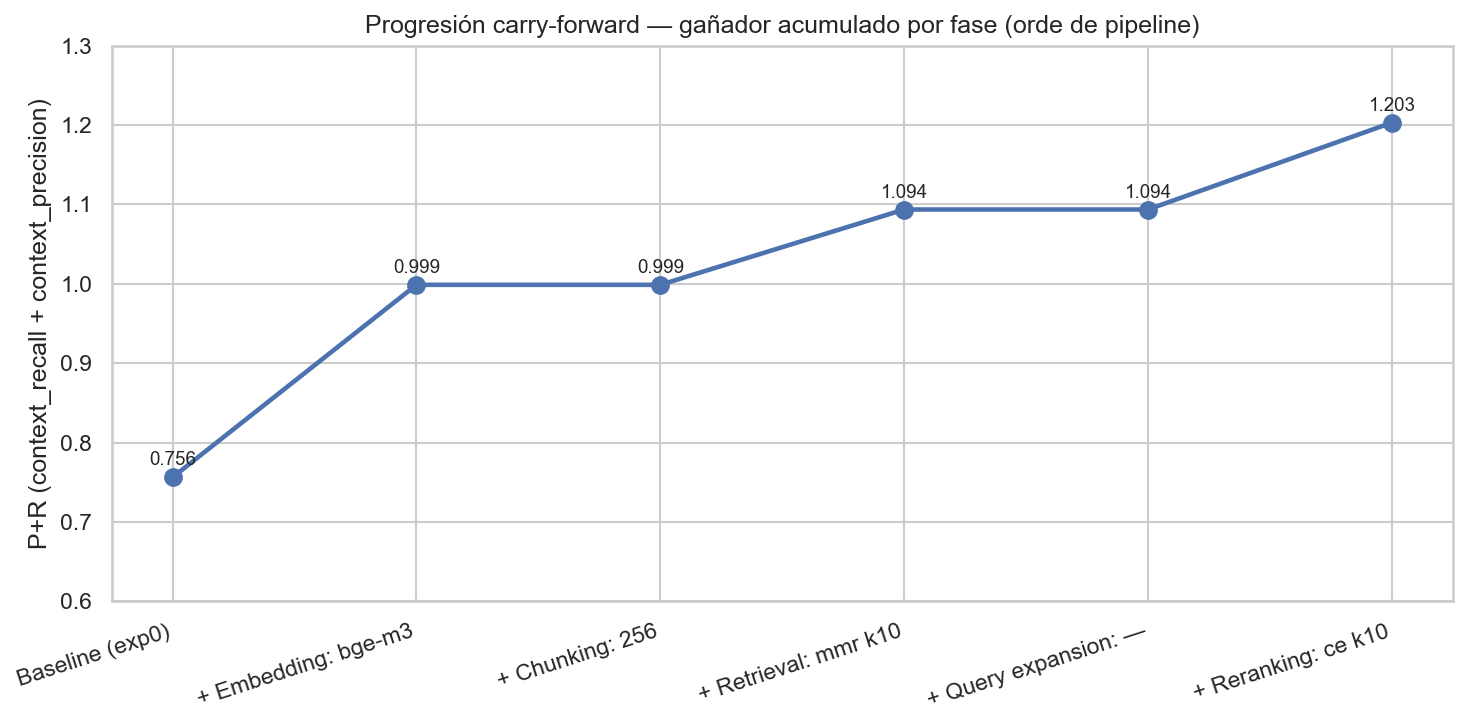

,fase,P+R,Δ
0,Baseline (exp0),0.7564,0.0000
1,+ Embedding: bge-m3,0.9987,0.2423
2,+ Chunking: 256,0.9987,0.0000
3,+ Retrieval: mmr k10,1.0935,0.0948
4,+ Query expansion: —,1.0935,0.0000
5,+ Reranking: ce k10,1.2029,0.1094


In [2]:
prog = [
    ('Baseline (exp0)',          'exp0'),
    ('+ Embedding: bge-m3',      'exp1__bge_m3'),
    ('+ Chunking: 256',          'exp1__bge_m3'),
    ('+ Retrieval: mmr k10',     'exp3__mmr_k10'),
    ('+ Query expansion: —',     'exp3__mmr_k10'),
    ('+ Reranking: ce k10',      'exp5b__rerank_ce_k10'),
]
rows = [{'fase': lb, 'P+R': (lambda m: m['context_recall'] + m['context_precision'])(load(e))} for lb, e in prog]
prog_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(prog_df)), prog_df['P+R'], marker='o', color='#4C72B0', lw=2.2, markersize=8)
for i, v in enumerate(prog_df['P+R']):
    ax.text(i, v + 0.015, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xticks(range(len(prog_df)))
ax.set_xticklabels(prog_df['fase'], rotation=18, ha='right')
ax.set_ylabel('P+R (context_recall + context_precision)')
ax.set_ylim(0.6, 1.3)
ax.set_title('Progresión carry-forward — gañador acumulado por fase (orde de pipeline)')
plt.tight_layout()
plt.savefig(FIGURES / 'progression.pdf'); plt.savefig(FIGURES / 'progression.png')
plt.show()

prog_df['Δ'] = prog_df['P+R'].diff().fillna(0).round(4)
display(prog_df.round(4))
prog_df.to_csv(TABLES / 'progression.csv', index=False)

### 1.1 Variación de cada métrica por decisión

Como evoluciona **cada unha das 6 métricas** ao longo da cadea de decisións (gañador acumulado). O *heatmap* mostra o Δ de cada métrica en cada decisión: verde = mellora, vermello = empeora.

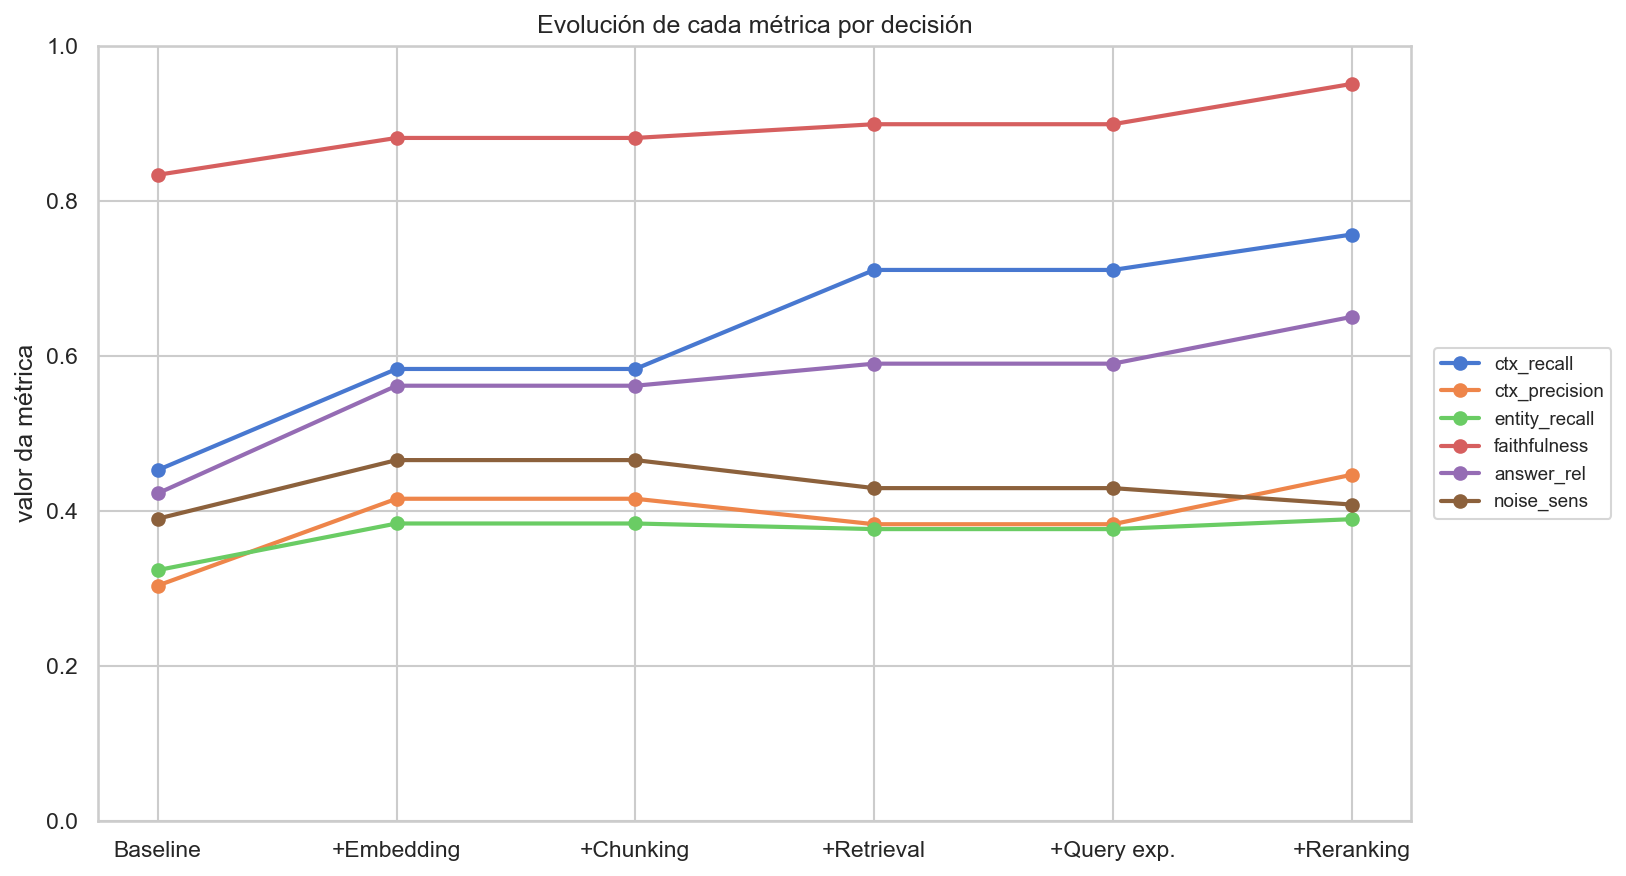

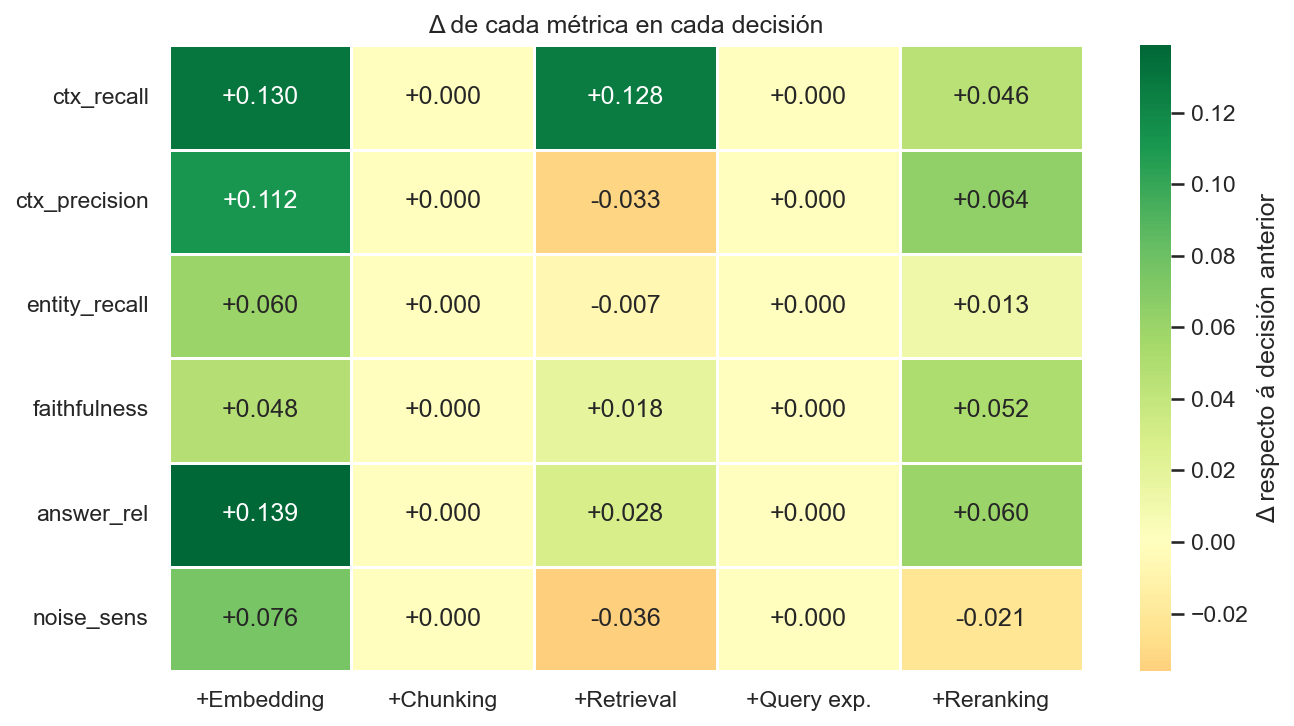

,Baseline,+Embedding,+Chunking,+Retrieval,+Query exp.,+Reranking
ctx_recall,0.4527,0.5830,0.5830,0.7107,0.7107,0.7563
ctx_precision,0.3037,0.4157,0.4157,0.3829,0.3829,0.4466
entity_recall,0.3237,0.3838,0.3838,0.3766,0.3766,0.3894
faithfulness,0.8333,0.8808,0.8808,0.8985,0.8985,0.9505
answer_rel,0.4226,0.5614,0.5614,0.5898,0.5898,0.6502
noise_sens,0.3900,0.4655,0.4655,0.4294,0.4294,0.4082


In [3]:
# Cadea de decisións (gañador acumulado) con TODAS as métricas
chain = [
    ('Baseline',    'exp0'),
    ('+Embedding',  'exp1__bge_m3'),
    ('+Chunking',   'exp1__bge_m3'),
    ('+Retrieval',  'exp3__mmr_k10'),
    ('+Query exp.', 'exp3__mmr_k10'),
    ('+Reranking',  'exp5b__rerank_ce_k10'),
]
mat = pd.DataFrame({lb: {SHORT[k]: load(e).get(k, np.nan) for k in METRICS} for lb, e in chain})
mat = mat.loc[[SHORT[k] for k in METRICS]]  # orde estable

# (a) liñas: cada métrica ao longo das decisións
fig, ax = plt.subplots(figsize=(11, 6))
for metric in mat.index:
    ax.plot(mat.columns, mat.loc[metric], marker='o', lw=2, label=metric)
ax.set_ylabel('valor da métrica'); ax.set_ylim(0, 1)
ax.set_title('Evolución de cada métrica por decisión')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'metrics_evolution.pdf'); plt.savefig(FIGURES / 'metrics_evolution.png')
plt.show()

# (b) heatmap de deltas: que decisión moveu que métrica
deltas = mat.diff(axis=1).iloc[:, 1:]  # quitar baseline (sen Δ)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(deltas, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Δ respecto á decisión anterior'}, ax=ax)
ax.set_title('Δ de cada métrica en cada decisión')
plt.tight_layout()
plt.savefig(FIGURES / 'metrics_delta_heatmap.pdf'); plt.savefig(FIGURES / 'metrics_delta_heatmap.png')
plt.show()

display(mat.round(4))
mat.round(4).to_csv(TABLES / 'metrics_by_decision.csv')

## 2. Embeddings (exp1)

Comparativa de modelos de incrustación (resto fixo ao baseline). Liña base: bge-base-en-v1.5 (exp0).

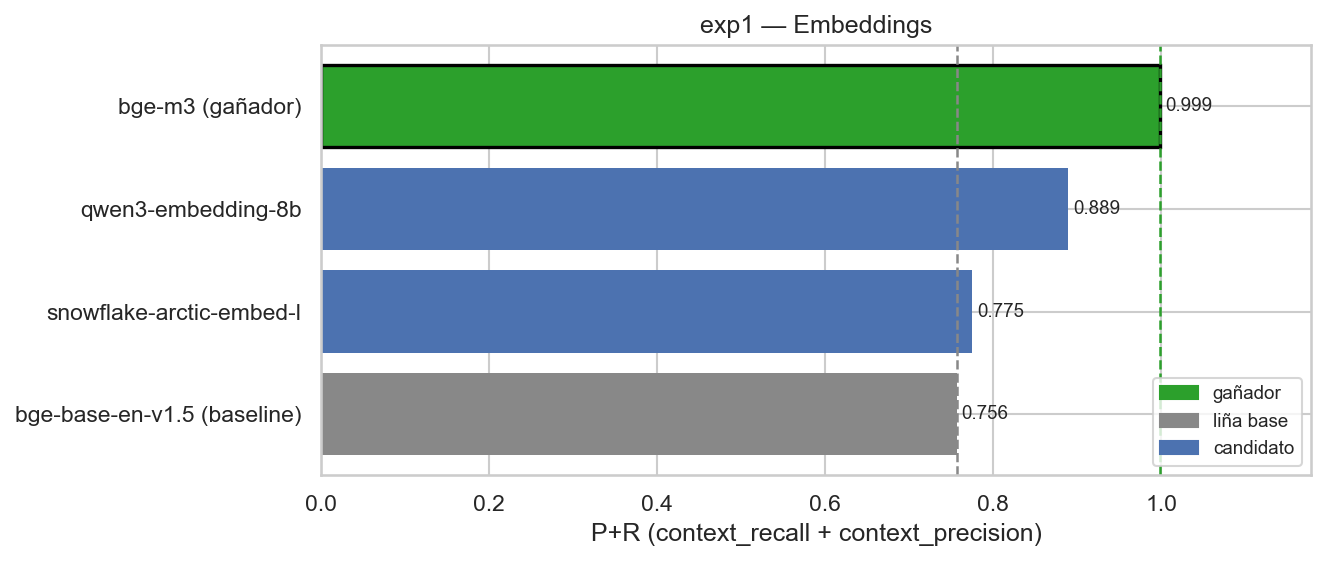

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,bge-base-en-v1.5 (baseline),0.4527,0.3037,0.3237,0.8333,0.4226,0.3900,0.7564
1,snowflake-arctic-embed-l,0.4627,0.3121,0.3252,0.8430,0.4559,0.3585,0.7747
2,qwen3-embedding-8b,0.5023,0.3865,0.3084,0.8655,0.4561,0.3529,0.8888
3,bge-m3 (gañador),0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987


,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,bge-base-en-v1.5 (baseline),0.4527,0.3037,0.3237,0.8333,0.4226,0.3900,0.7564
1,snowflake-arctic-embed-l,0.4627,0.3121,0.3252,0.8430,0.4559,0.3585,0.7747
2,qwen3-embedding-8b,0.5023,0.3865,0.3084,0.8655,0.4561,0.3529,0.8888
3,bge-m3 (gañador),0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987


In [4]:
emb = table([
    ('bge-base-en-v1.5 (baseline)', 'exp0', 'base'),
    ('snowflake-arctic-embed-l',    'exp1__snowflake_arctic_l', 'cand'),
    ('qwen3-embedding-8b',          'exp1__qwen3_8b', 'cand'),
    ('bge-m3 (gañador)',            'exp1__bge_m3', 'win'),
])
plot_pr(emb, 'exp1 — Embeddings', 'exp1_embeddings')
show(emb, 'exp1_embeddings')

## 3. Fragmentación / *chunking* (exp2)

Estratexias de troceado (embedding fixo = bge-m3). A liña base é fixed 256 (a configuración herdada de exp1), que tamén resulta **gañadora** → represéntase raiada (gañador = liña base).

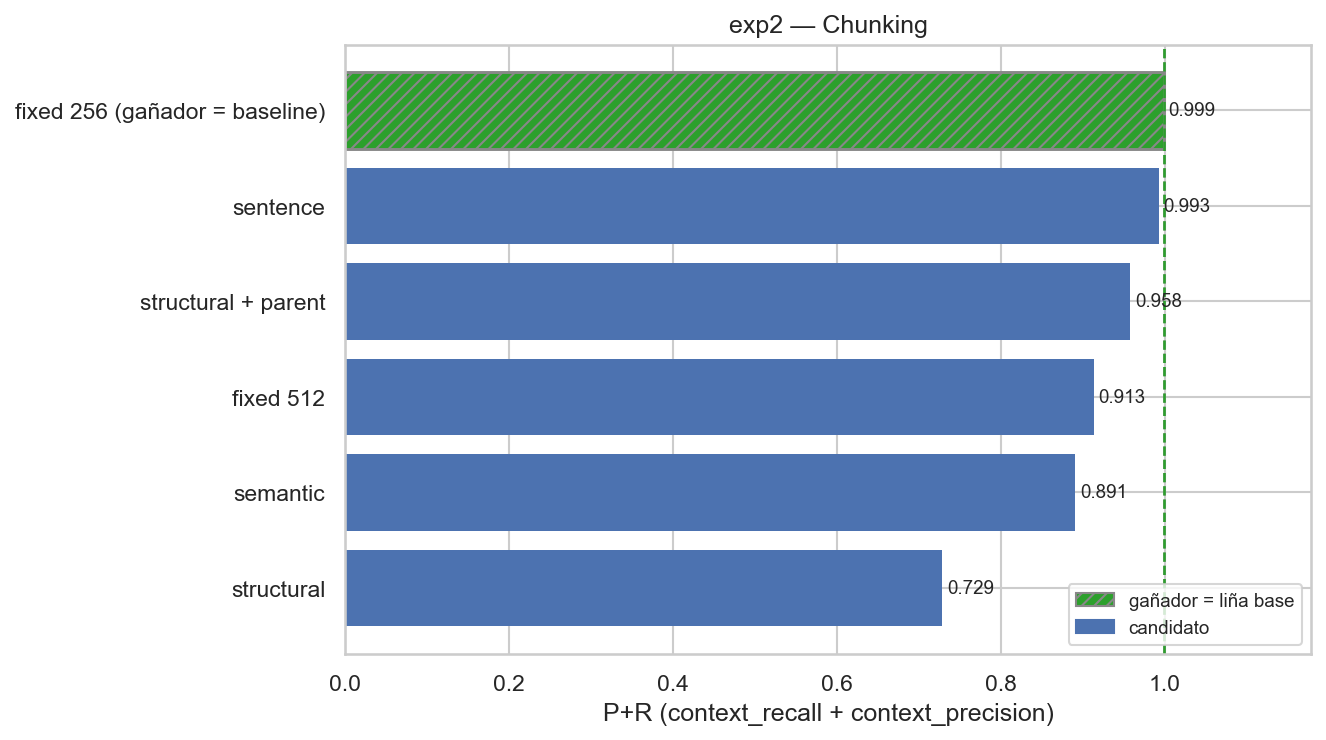

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,fixed 256 (gañador = baseline),0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987
1,fixed 512,0.5800,0.3332,0.3557,0.8052,0.4785,0.4254,0.9132
2,sentence,0.6150,0.3777,0.3615,0.8701,0.4603,0.4052,0.9927
3,structural,0.4473,0.2814,0.3235,0.8910,0.4601,0.3842,0.7288
4,structural + parent,0.5903,0.3675,0.3484,0.8490,0.4381,0.4199,0.9579
5,semantic,0.5937,0.2973,0.3463,0.8660,0.4619,0.4709,0.8910


,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,fixed 256 (gañador = baseline),0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987
1,fixed 512,0.5800,0.3332,0.3557,0.8052,0.4785,0.4254,0.9132
2,sentence,0.6150,0.3777,0.3615,0.8701,0.4603,0.4052,0.9927
3,structural,0.4473,0.2814,0.3235,0.8910,0.4601,0.3842,0.7288
4,structural + parent,0.5903,0.3675,0.3484,0.8490,0.4381,0.4199,0.9579
5,semantic,0.5937,0.2973,0.3463,0.8660,0.4619,0.4709,0.8910


In [5]:
chunk = table([
    ('fixed 256 (gañador = baseline)', 'exp1__bge_m3', 'winbase'),
    ('fixed 512',            'exp2__fixed_512', 'cand'),
    ('sentence',             'exp2__sentence', 'cand'),
    ('structural',           'exp2__structural', 'cand'),
    ('structural + parent',  'exp2__structural_pc', 'cand'),
    ('semantic',             'exp2__semantic', 'cand'),
])
plot_pr(chunk, 'exp2 — Chunking', 'exp2_chunking')
show(chunk, 'exp2_chunking')

## 4. Recuperación (exp3)

Estratexias de recuperación a k=10 fronte á liña base (cosine k5). mmr acada o mellor equilibrio (sobe moito o recall).

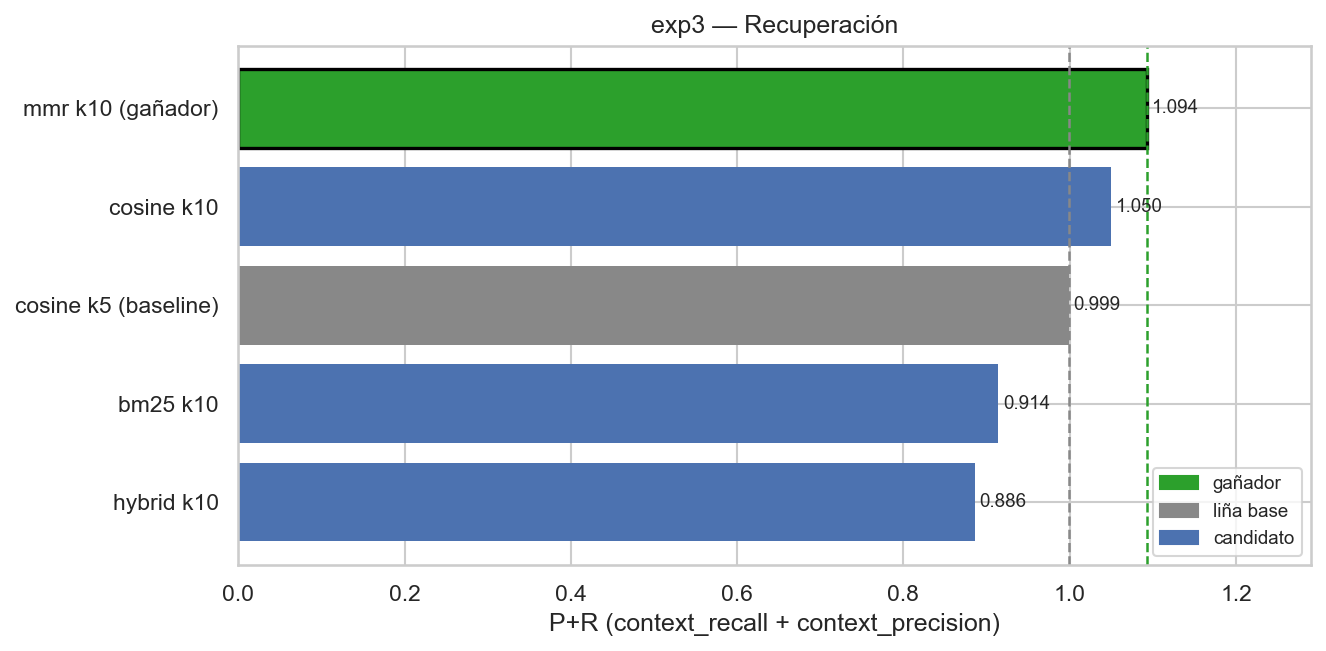

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,cosine k5 (baseline),0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987
1,cosine k10,0.6437,0.4063,0.3860,0.9045,0.5752,0.3923,1.0499
2,bm25 k10,0.6560,0.2580,0.3835,0.8259,0.4025,0.4089,0.9140
3,hybrid k10,0.6140,0.2718,0.3689,0.8447,0.5655,0.3779,0.8858
4,mmr k10 (gañador),0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935


,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,cosine k5 (baseline),0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987
1,cosine k10,0.6437,0.4063,0.3860,0.9045,0.5752,0.3923,1.0499
2,bm25 k10,0.6560,0.2580,0.3835,0.8259,0.4025,0.4089,0.9140
3,hybrid k10,0.6140,0.2718,0.3689,0.8447,0.5655,0.3779,0.8858
4,mmr k10 (gañador),0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935


In [6]:
retr = table([
    ('cosine k5 (baseline)', 'exp1__bge_m3', 'base'),
    ('cosine k10',           'exp3__dense_k10', 'cand'),
    ('bm25 k10',             'exp3__bm25_k10', 'cand'),
    ('hybrid k10',           'exp3__hybrid_k10', 'cand'),
    ('mmr k10 (gañador)',    'exp3__mmr_k10', 'win'),
])
plot_pr(retr, 'exp3 — Recuperación', 'exp3_retrieval')
show(retr, 'exp3_retrieval')

## 5. Expansión de consulta (exp4)

Sete técnicas de transformación de consulta (pre-retrieval), avaliadas en illado sobre mmr, fronte á **súa liña base (mmr k10)**. **Ningunha supera a liña base** — degradan, sobre todo o recall. (O campión global ce k10 non se inclúe aquí: é doutra fase —reranking, post-retrieval— e non é comparable *ceteris paribus*.)

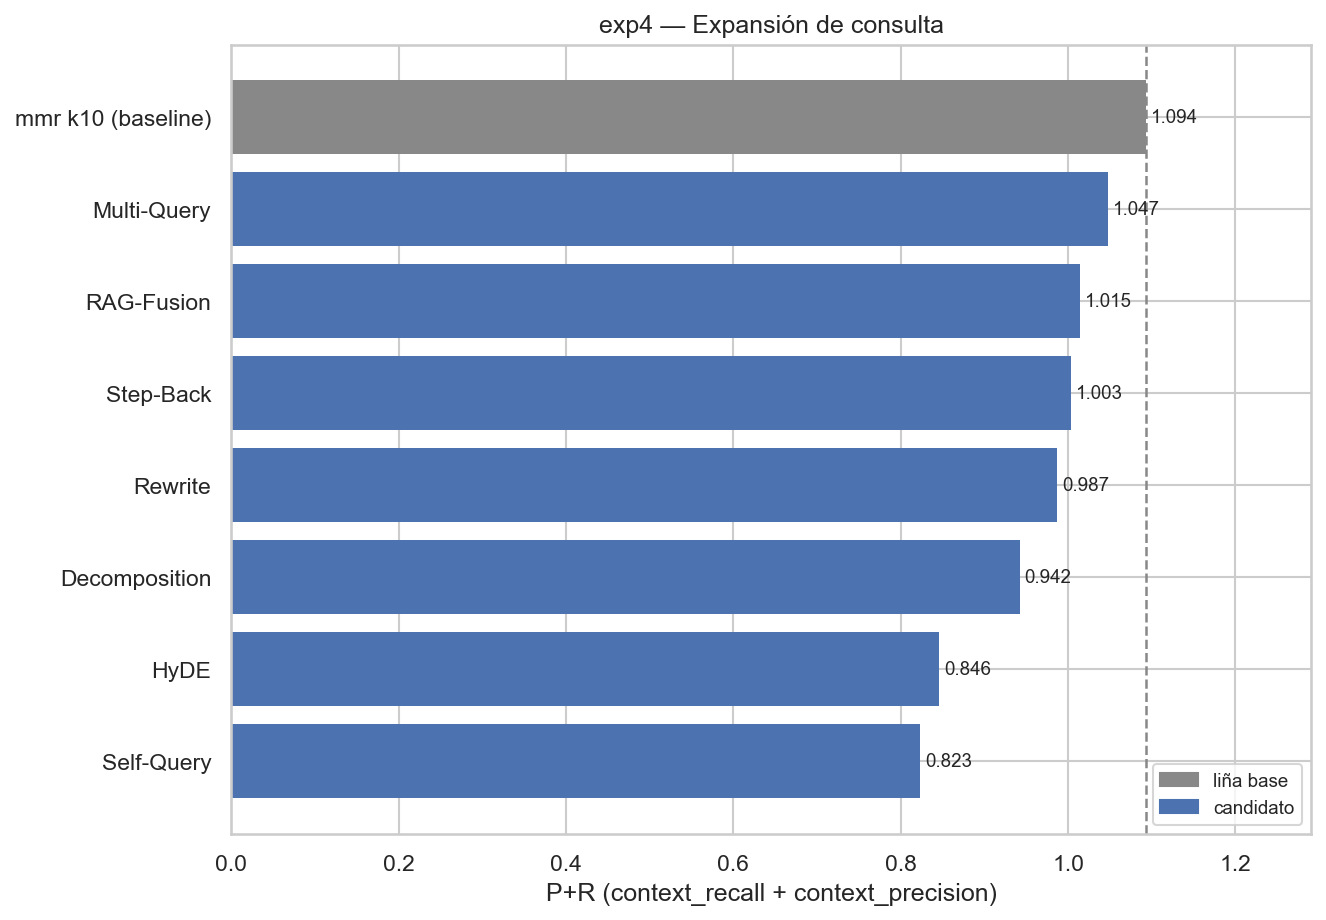

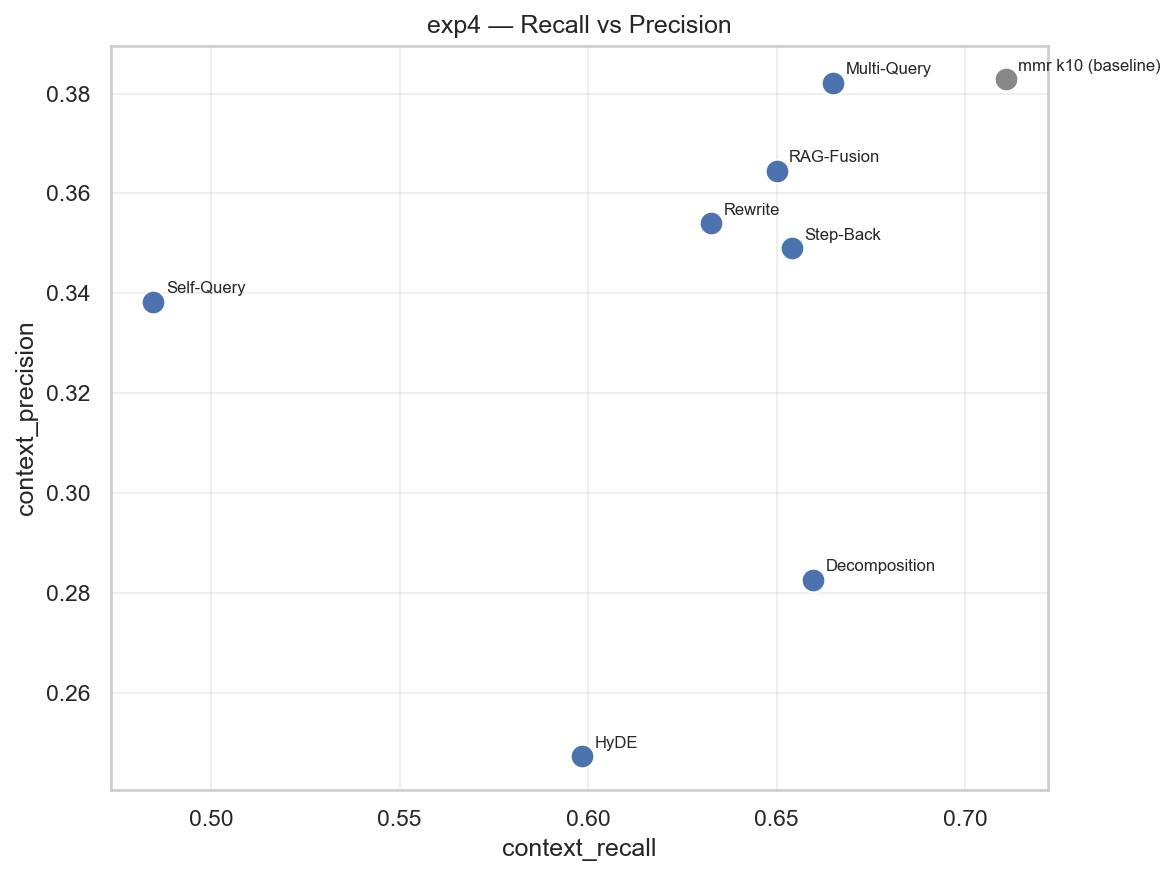

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,mmr k10 (baseline),0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935
1,HyDE,0.5983,0.2473,0.3358,0.8767,0.5593,0.3968,0.8456
2,Multi-Query,0.6650,0.3822,0.3889,0.8782,0.5815,0.4223,1.0472
3,RAG-Fusion,0.6500,0.3646,0.3585,0.9176,0.5146,0.3866,1.0146
4,Rewrite,0.6327,0.3541,0.3539,0.9375,0.5676,0.4076,0.9867
5,Step-Back,0.6540,0.3490,0.3408,0.8949,0.5441,0.3390,1.0030
6,Decomposition,0.6597,0.2826,0.3825,0.9193,0.5933,0.4195,0.9423
7,Self-Query,0.4847,0.3383,0.2355,0.8100,0.4377,0.3537,0.8230


,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,mmr k10 (baseline),0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935
1,HyDE,0.5983,0.2473,0.3358,0.8767,0.5593,0.3968,0.8456
2,Multi-Query,0.6650,0.3822,0.3889,0.8782,0.5815,0.4223,1.0472
3,RAG-Fusion,0.6500,0.3646,0.3585,0.9176,0.5146,0.3866,1.0146
4,Rewrite,0.6327,0.3541,0.3539,0.9375,0.5676,0.4076,0.9867
5,Step-Back,0.6540,0.3490,0.3408,0.8949,0.5441,0.3390,1.0030
6,Decomposition,0.6597,0.2826,0.3825,0.9193,0.5933,0.4195,0.9423
7,Self-Query,0.4847,0.3383,0.2355,0.8100,0.4377,0.3537,0.8230


In [7]:
qe = table([
    ('mmr k10 (baseline)',   'exp3__mmr_k10', 'base'),
    ('HyDE',                 'exp4a__hyde', 'cand'),
    ('Multi-Query',          'exp4b__multiquery', 'cand'),
    ('RAG-Fusion',           'exp4c__rag_fusion', 'cand'),
    ('Rewrite',              'exp4d__rewrite', 'cand'),
    ('Step-Back',            'exp4e__stepback', 'cand'),
    ('Decomposition',        'exp4f__decomposition', 'cand'),
    ('Self-Query',           'exp4g__selfquery', 'cand'),
])
plot_pr(qe, 'exp4 — Expansión de consulta', 'exp4_query_expansion')

# Recall vs precision (ilustra o trade-off)
fig, ax = plt.subplots(figsize=(8, 6))
for _, r in qe.iterrows():
    ax.scatter(r['context_recall'], r['context_precision'], s=130, c=COL[r['kind']], edgecolors='white', zorder=3)
    ax.annotate(r['config'], (r['context_recall'], r['context_precision']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('context_recall'); ax.set_ylabel('context_precision')
ax.set_title('exp4 — Recall vs Precision'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'exp4_recall_precision.pdf'); plt.savefig(FIGURES / 'exp4_recall_precision.png')
plt.show()

show(qe, 'exp4_query_expansion')

## 6. Reordenamento / *reranking* (exp5)

Reranking en fervenza (pool 50 → 20 diversos por mmr → reranker → top_k) fronte á recuperación sen rerank (mmr k10). O cross-encoder recupera a precisión e segue subindo recall — é a etapa que achega a mellora final.

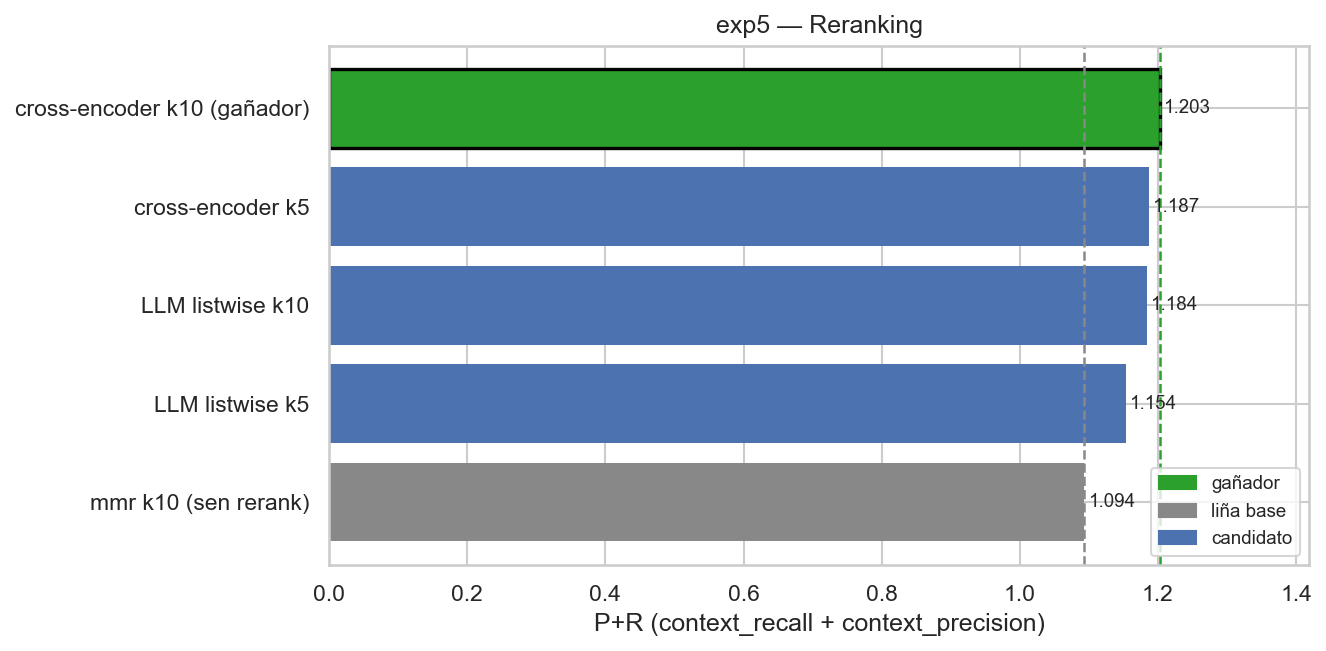

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,mmr k10 (sen rerank),0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935
1,cross-encoder k5,0.7083,0.4791,0.3739,0.9241,0.5557,0.4033,1.1874
2,LLM listwise k5,0.6655,0.4881,0.3809,0.9011,0.5729,0.3810,1.1536
3,LLM listwise k10,0.7210,0.4627,0.4414,0.8896,0.5786,0.4324,1.1837
4,cross-encoder k10 (gañador),0.7563,0.4466,0.3894,0.9505,0.6502,0.4082,1.2029


,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,mmr k10 (sen rerank),0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935
1,cross-encoder k5,0.7083,0.4791,0.3739,0.9241,0.5557,0.4033,1.1874
2,LLM listwise k5,0.6655,0.4881,0.3809,0.9011,0.5729,0.3810,1.1536
3,LLM listwise k10,0.7210,0.4627,0.4414,0.8896,0.5786,0.4324,1.1837
4,cross-encoder k10 (gañador),0.7563,0.4466,0.3894,0.9505,0.6502,0.4082,1.2029


In [8]:
rer = table([
    ('mmr k10 (sen rerank)',     'exp3__mmr_k10', 'base'),
    ('cross-encoder k5',         'exp5a__rerank_ce_k5', 'cand'),
    ('LLM listwise k5',          'exp5c__rerank_llm_k5', 'cand'),
    ('LLM listwise k10',         'exp5d__rerank_llm_k10', 'cand'),
    ('cross-encoder k10 (gañador)', 'exp5b__rerank_ce_k10', 'win'),
])
plot_pr(rer, 'exp5 — Reranking', 'exp5_reranking')
show(rer, 'exp5_reranking')

## 7. Pipeline final — desagregación das 6 métricas

Comparación das seis métricas RAGAS entre a liña base (exp0) e o pipeline final gañador (ce k10). Mellora en todas as dimensións de recuperación e xeración.

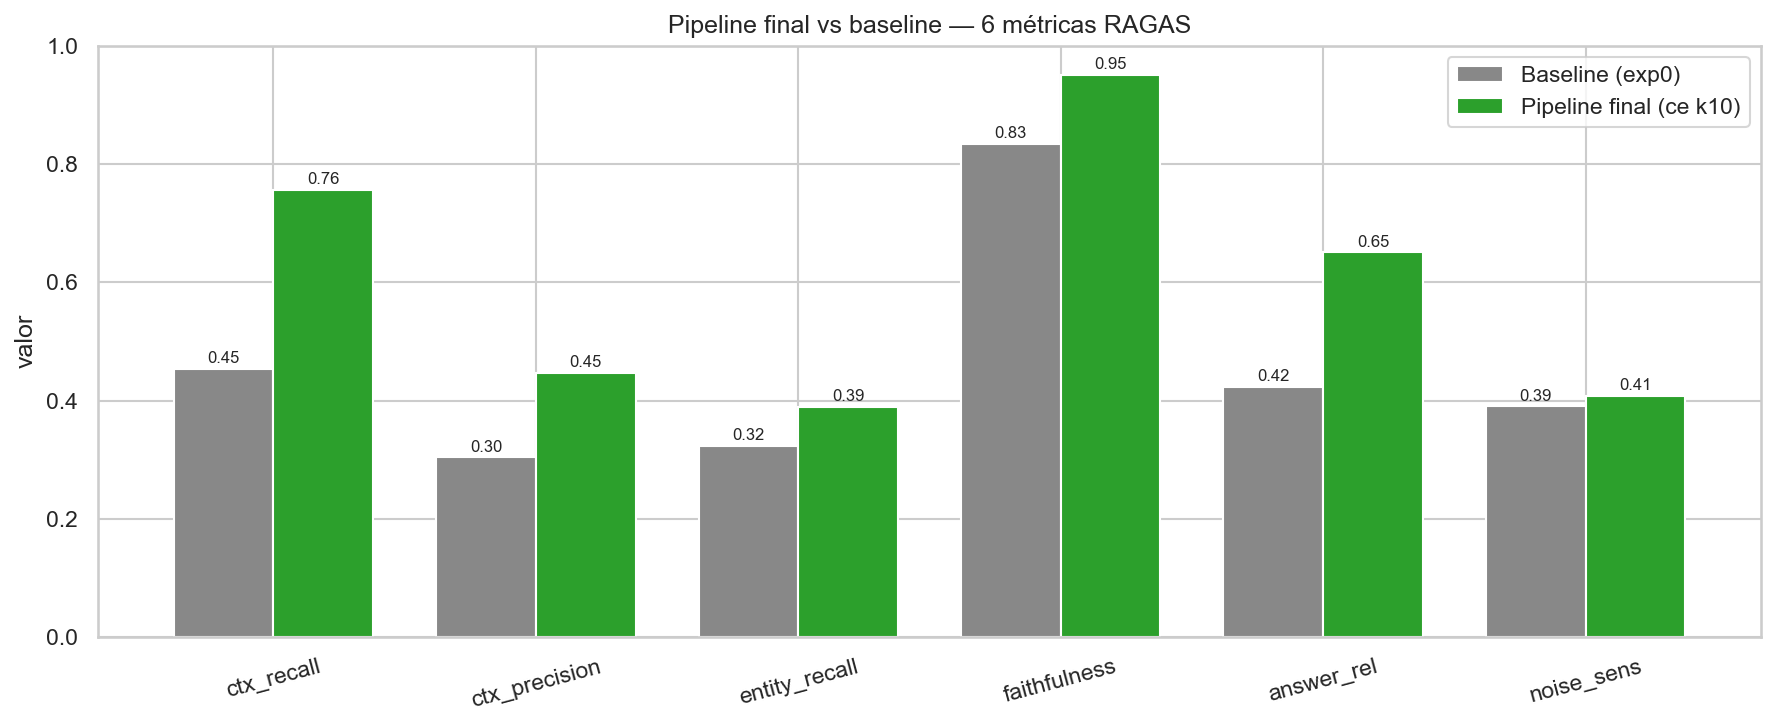

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,Baseline (exp0),0.4527,0.3037,0.3237,0.8333,0.4226,0.3900,0.7564
1,Pipeline final (ce k10),0.7563,0.4466,0.3894,0.9505,0.6502,0.4082,1.2029


,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,Baseline (exp0),0.4527,0.3037,0.3237,0.8333,0.4226,0.3900,0.7564
1,Pipeline final (ce k10),0.7563,0.4466,0.3894,0.9505,0.6502,0.4082,1.2029


In [9]:
fin = table([
    ('Baseline (exp0)',          'exp0', 'base'),
    ('Pipeline final (ce k10)',  'exp5b__rerank_ce_k10', 'win'),
])
short = [SHORT[k] for k in METRICS]
x = np.arange(len(METRICS)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, fin.iloc[0][METRICS].values, w, label=fin.iloc[0]['config'], color=COL['base'])
ax.bar(x + w/2, fin.iloc[1][METRICS].values, w, label=fin.iloc[1]['config'], color=COL['win'])
for i, k in enumerate(METRICS):
    ax.text(i - w/2, fin.iloc[0][k] + 0.01, f"{fin.iloc[0][k]:.2f}", ha='center', fontsize=8)
    ax.text(i + w/2, fin.iloc[1][k] + 0.01, f"{fin.iloc[1][k]:.2f}", ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short, rotation=15)
ax.set_ylabel('valor'); ax.set_ylim(0, 1.0)
ax.set_title('Pipeline final vs baseline — 6 métricas RAGAS')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'final_metrics.pdf'); plt.savefig(FIGURES / 'final_metrics.png')
plt.show()
show(fin, 'final_metrics')

## 8. Táboa mestra

Todas as configuracións avaliadas e as súas métricas nun único cadro (ordenado por P+R).

In [10]:
master_rows = [
    ('Baseline',        'baseline',       'exp0'),
    ('Embeddings',      'snowflake-arctic-l', 'exp1__snowflake_arctic_l'),
    ('Embeddings',      'qwen3-8b',       'exp1__qwen3_8b'),
    ('Embeddings',      'bge-m3',         'exp1__bge_m3'),
    ('Chunking',        'fixed 512',      'exp2__fixed_512'),
    ('Chunking',        'sentence',       'exp2__sentence'),
    ('Chunking',        'structural',     'exp2__structural'),
    ('Chunking',        'structural+pc',  'exp2__structural_pc'),
    ('Chunking',        'semantic',       'exp2__semantic'),
    ('Retrieval',       'cosine k10',     'exp3__dense_k10'),
    ('Retrieval',       'bm25 k10',       'exp3__bm25_k10'),
    ('Retrieval',       'hybrid k10',     'exp3__hybrid_k10'),
    ('Retrieval',       'mmr k10',        'exp3__mmr_k10'),
    ('Query expansion', 'hyde',           'exp4a__hyde'),
    ('Query expansion', 'multiquery',     'exp4b__multiquery'),
    ('Query expansion', 'rag_fusion',     'exp4c__rag_fusion'),
    ('Query expansion', 'rewrite',        'exp4d__rewrite'),
    ('Query expansion', 'stepback',       'exp4e__stepback'),
    ('Query expansion', 'decomposition',  'exp4f__decomposition'),
    ('Query expansion', 'selfquery',      'exp4g__selfquery'),
    ('Reranking',       'ce k5',          'exp5a__rerank_ce_k5'),
    ('Reranking',       'ce k10',         'exp5b__rerank_ce_k10'),
    ('Reranking',       'llm k5',         'exp5c__rerank_llm_k5'),
    ('Reranking',       'llm k10',        'exp5d__rerank_llm_k10'),
]
rows = []
for fase, cfg, e in master_rows:
    m = load(e)
    d = {'fase': fase, 'config': cfg}
    for k in METRICS:
        d[k] = round(m.get(k, np.nan), 4)
    d['P+R'] = round(m['context_recall'] + m['context_precision'], 4)
    rows.append(d)
master = pd.DataFrame(rows).sort_values('P+R', ascending=False).reset_index(drop=True)
display(master)
master.to_csv(TABLES / 'master_results.csv', index=False)
print('\nGañador global:', master.iloc[0]['fase'], '·', master.iloc[0]['config'], '· P+R =', master.iloc[0]['P+R'])

,fase,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,Reranking,ce k10,0.7563,0.4466,0.3894,0.9505,0.6502,0.4082,1.2029
1,Reranking,ce k5,0.7083,0.4791,0.3739,0.9241,0.5557,0.4033,1.1874
2,Reranking,llm k10,0.7210,0.4627,0.4414,0.8896,0.5786,0.4324,1.1837
3,Reranking,llm k5,0.6655,0.4881,0.3809,0.9011,0.5729,0.3810,1.1536
4,Retrieval,mmr k10,0.7107,0.3829,0.3766,0.8985,0.5898,0.4294,1.0935
5,Retrieval,cosine k10,0.6437,0.4063,0.3860,0.9045,0.5752,0.3923,1.0499
6,Query expansion,multiquery,0.6650,0.3822,0.3889,0.8782,0.5815,0.4223,1.0472
7,Query expansion,rag_fusion,0.6500,0.3646,0.3585,0.9176,0.5146,0.3866,1.0146
8,Query expansion,stepback,0.6540,0.3490,0.3408,0.8949,0.5441,0.3390,1.0030
9,Embeddings,bge-m3,0.5830,0.4157,0.3838,0.8808,0.5614,0.4655,0.9987



Gañador global: Reranking · ce k10 · P+R = 1.2029


## 9. Stack SOTA-sobre-papel vs cadea empírica

Contraste final: a **cadea optimizada empíricamente** (carry-forward: bge-m3 + fixed 256 + mmr + cross-encoder) fronte a un **stack que combina a técnica máis avanzada de cada dimensión** (qwen3-8b + semantic + hybrid + RAG-Fusion + LLM listwise rerank). Resultado: o stack "todo SOTA" **NON supera** o axuste empírico — de feito queda ao nivel do baseline mmr (1.095 ≈ 1.094) e por debaixo da cadea empírica (1.203) en todas as métricas.

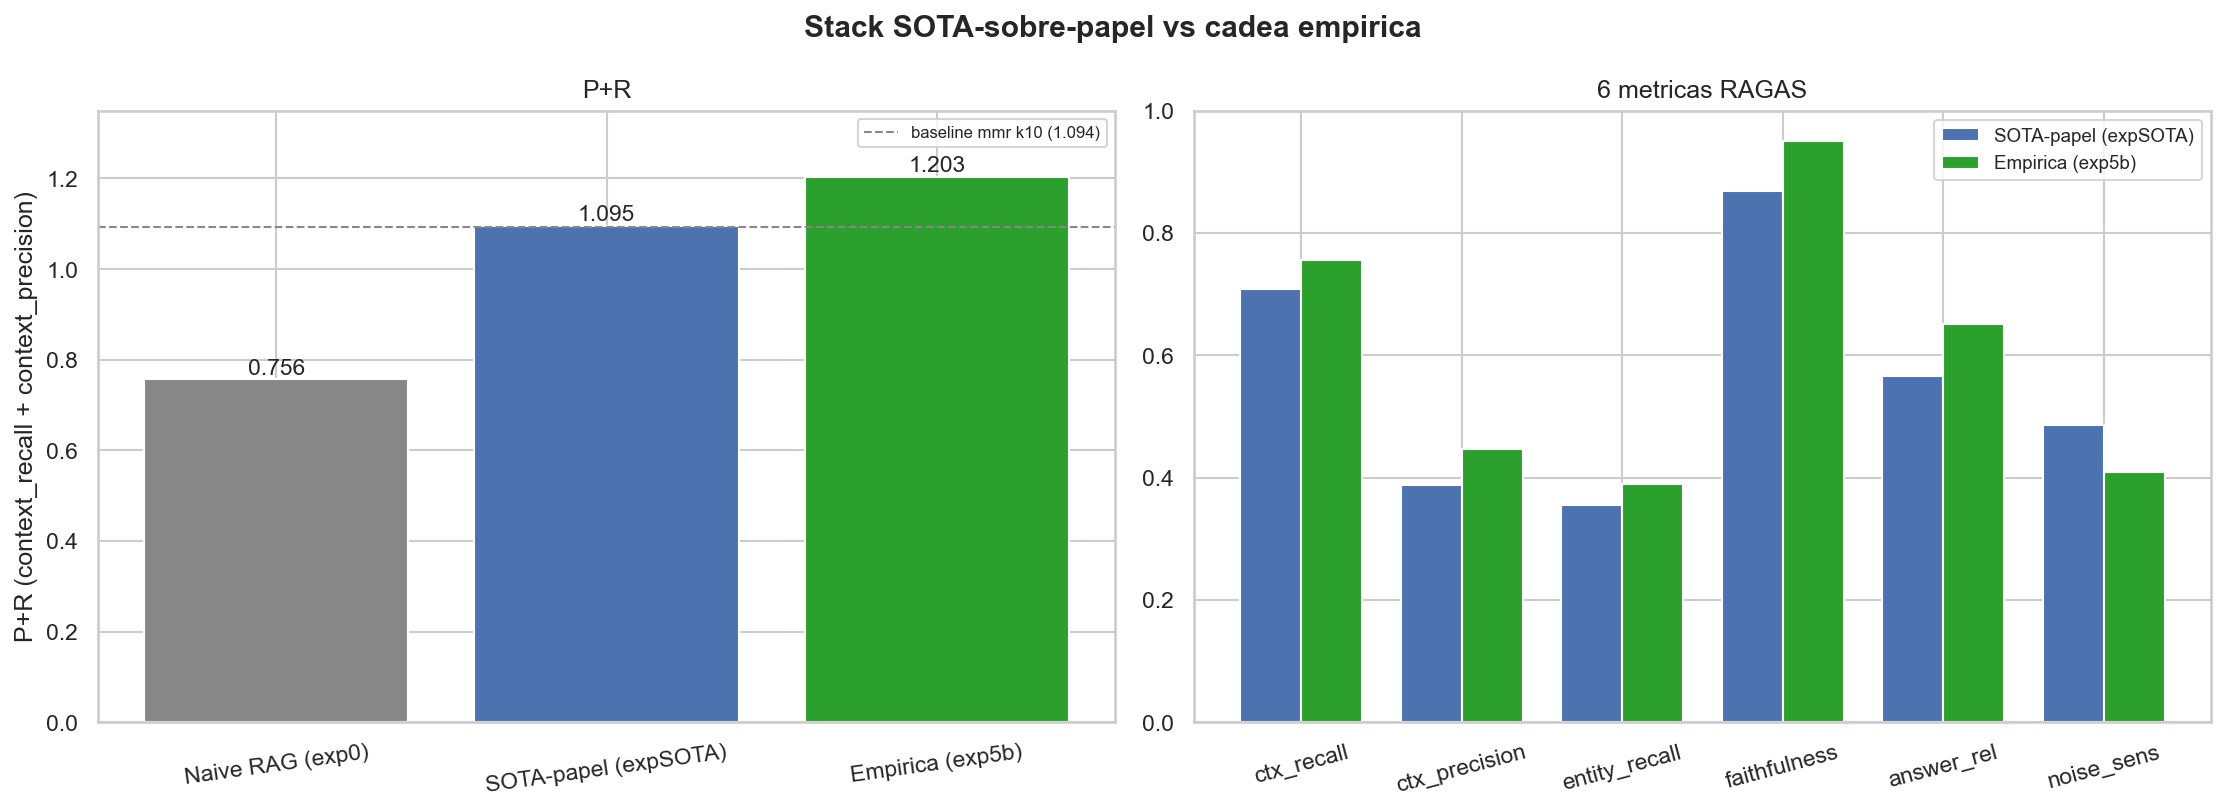

,config,context_recall,context_precision,context_entity_recall,faithfulness,answer_relevancy,noise_sensitivity(mode=relevant),P+R
0,Naive RAG (exp0),0.4527,0.3037,0.3237,0.8333,0.4226,0.3900,0.7564
1,SOTA-papel (expSOTA),0.7077,0.3873,0.3545,0.8689,0.5664,0.4861,1.0950
2,Empirica (exp5b),0.7563,0.4466,0.3894,0.9505,0.6502,0.4082,1.2029


SOTA-papel 1.095  vs  empirica 1.203  ->  diferencia -0.108 (gana a empirica)


In [11]:
comp = [
    ('Naive RAG (exp0)',        'exp0', COL['base']),
    ('SOTA-papel (expSOTA)',    'expSOTA', COL['cand']),
    ('Empirica (exp5b)',        'exp5b__rerank_ce_k10', COL['win']),
]
rows = []
for lb, e, c in comp:
    m = load(e)
    d = {'config': lb, 'exp': e, 'color': c}
    for k in METRICS: d[k] = m.get(k, np.nan)
    d['P+R'] = m['context_recall'] + m['context_precision']
    rows.append(d)
cdf = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
bars = ax1.bar(cdf['config'], cdf['P+R'], color=cdf['color'])
for b, v in zip(bars, cdf['P+R']):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.3f}', ha='center', fontsize=11)
ax1.axhline(1.0935, ls='--', c='#888888', lw=1, label='baseline mmr k10 (1.094)')
ax1.set_ylabel('P+R (context_recall + context_precision)'); ax1.set_ylim(0, 1.35)
ax1.set_title('P+R'); ax1.legend(fontsize=8); plt.setp(ax1.get_xticklabels(), rotation=8)

sota = cdf[cdf['exp'] == 'expSOTA'].iloc[0]
emp = cdf[cdf['exp'] == 'exp5b__rerank_ce_k10'].iloc[0]
x = np.arange(len(METRICS)); w = 0.38
ax2.bar(x - w/2, [sota[k] for k in METRICS], w, label='SOTA-papel (expSOTA)', color=COL['cand'])
ax2.bar(x + w/2, [emp[k] for k in METRICS], w, label='Empirica (exp5b)', color=COL['win'])
ax2.set_xticks(x); ax2.set_xticklabels([SHORT[k] for k in METRICS], rotation=15)
ax2.set_ylim(0, 1); ax2.set_title('6 metricas RAGAS'); ax2.legend(fontsize=9)
fig.suptitle('Stack SOTA-sobre-papel vs cadea empirica', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'sota_stack_vs_empirical.pdf'); plt.savefig(FIGURES / 'sota_stack_vs_empirical.png')
plt.show()
show(cdf, 'sota_stack_vs_empirical')
print(f"SOTA-papel {sota['P+R']:.3f}  vs  empirica {emp['P+R']:.3f}  ->  diferencia {sota['P+R']-emp['P+R']:+.3f} (gana a empirica)")

## Conclusións

- **Embedding** é a panca con maior impacto: bge-m3 sobe o P+R de 0.756 a 0.999 (+0.243).
- **Chunking** fixed 256 é óptimo; estruturas máis complexas (sentence, structural, semantic) non melloran.
- **mmr** supera a cosine/bm25/hybrid; o **reranking cross-encoder** achega o empuxe final de precisión.
- As sete técnicas de **expansión de consulta degradan** sobre un retriever denso forte nun dominio xurídico preciso — resultado negativo coherente coa literatura (a expansión é *subject-dependent*).
- **Cadea final:** bge-m3 → fixed 256/ov25 → mmr k10 → cross-encoder rerank · **P+R = 1.203** (+59 % sobre o baseline).
- O **stack SOTA-sobre-papel** (qwen3 + semantic + hybrid + RAG-Fusion + LLM rerank) **non supera** o axuste empírico (P+R **1.095 vs 1.203**) e queda ao nivel do baseline mmr. Confírmase que neste dominio o **tuning sistemático bate a aplicar o máis avanzado off-the-shelf** — *newer ≠ better*.